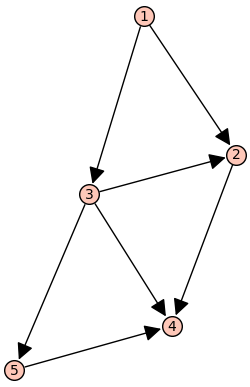

In [2]:
g = DiGraph(weighted = True)
g.add_edges([(1, 2, 8), (1,3,2), (2,4,1), (3,2,5), (3,4, 11), (3,5,1), (5, 4, 9)])
g.show()

In [3]:
M = g.weighted_adjacency_matrix()
print(M)

[ 0  8  2  0  0]
[ 0  0  0  1  0]
[ 0  5  0 11  1]
[ 0  0  0  0  0]
[ 0  0  0  9  0]


In [5]:
g.edges()

[(1, 2, 8), (1, 3, 2), (2, 4, 1), (3, 2, 5), (3, 4, 11), (3, 5, 1), (5, 4, 9)]

# EXERCICE 1

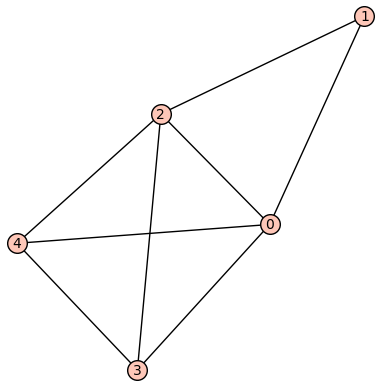

[0 2 4 3 6]
[2 0 7 0 0]
[4 7 0 2 8]
[3 0 2 0 1]
[6 0 8 1 0]


In [6]:

g2 = Graph(weighted = True)


g2.add_edges([
    (0, 1, 2), 
    (0, 2, 4), 
    (0, 3, 3),
    (0, 4, 6),
    (1, 2, 7), 
    (2, 3, 2),
    (2, 4, 8),
    (3, 4, 1)
    
])


g2.show()


M2 = g2.weighted_adjacency_matrix()
print(M2)

In [7]:
g = DiGraph(weighted = True)
g.add_edges([(1, 2, 8), (1,3,2), (2,4,1), (3,2,5), (3,4, 11), (3,5,1), (5, 4, 9)])
N = g.topological_sort()
print(N)

[1, 3, 2, 5, 4]


In [14]:
print(Infinity > 9999)
print(Infinity + 82 == Infinity)
print(Infinity + 1 > Infinity)
print(Infinity*(-72) == -Infinity)

True
True
False
True


In [ ]:
def bellman(g):
    N = g.topological_sort()
    n = g.order()
    D = n * [Infinity]
    D[0] = 0
    for i in range(1, n):
        pred =  []
        D[i] = min( [d(j) + f(j, i) for j in pred])
    return D




 

# EXERCICE : 2

In [29]:
# ON aura bésoin de la fonction prédecesseurs dans bellman vu que je l'ai déjà écrite:

def predecesseurs(g, sommet):
    pred = []                          
    liste_aretes = g.edges()           
    for arete in liste_aretes:         
        if arete[1] == sommet:         
            pred.append(arete[0])      
    return pred

# Ecrivons la fonction pour trouver la position de l'élément dans la liste

def trouver_position(liste, element):
    for k in range(len(liste)):
        if liste[k] == element:
            return k

# Ecrivons celle pour trouver le poids dans le graphe :

def trouver_poids(g, source, destination):
    liste_aretes = g.edges()
    for arete in liste_aretes:
        if arete[0] == source and arete[1] == destination:
            return arete[2]

# Ecrivons maintenant la fonction de Bellman:

def bellman(g):
    N = g.topological_sort()
    n = g.order()
    D = n * [Infinity]
    P = n * [0]
    D[0] = 0
    P[0] = N[0]

    for i in range(1, n):
        pred = predecesseurs(g, N[i])

        # d(i) = min de d(j) + f(j, i)
        distances = []
        for j in pred:
            pos = trouver_position(N, j)
            poids = trouver_poids(g, j, N[i])
            distances.append(D[pos] + poids)
        D[i] = min(distances)

        # chercher j0 = le prédécesseur qui donne ce minimum
        for j in pred:
            pos = trouver_position(N, j)
            poids = trouver_poids(g, j, N[i])
            if D[pos] + poids == D[i]:
                P[i] = j

    return D, P

D, P = bellman(g)
print("Ordre topologique :", N)
print("Distances :", D)
print("Prédécesseurs :", P)


Ordre topologique : ['debut', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'fin']
Distances : [0, 2, 7, 3, 8]
Prédécesseurs : [1, 1, 3, 3, 2]


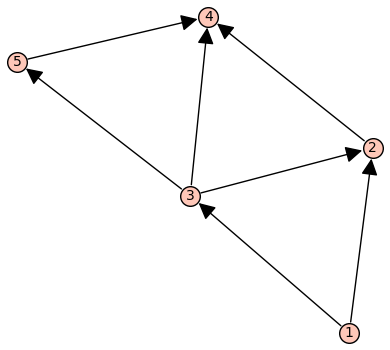

In [13]:
g = DiGraph(weighted = True)
g.add_edges([(1, 2, 8), (1,3,2), (2,4,1), (3,2,5), (3,4, 11), (3,5,1), (5, 4, 9)])
g.show()

# EXERCICE 3:

In [16]:
# Même chose que que la fonction bellman() on remplace juste +∞ par -∞ et min par max.

def plus_long_chemin(g):
    N = g.topological_sort()
    n = g.order()
    D = n * [-Infinity]
    P = n * [0]
    D[0] = 0
    P[0] = N[0]

    for i in range(1, n):
        pred = predecesseurs(g, N[i])

        distances = []
        for j in pred:
            pos = trouver_position(N, j)
            poids = trouver_poids(g, j, N[i])
            distances.append(D[pos] + poids)
        D[i] = max(distances)

        for j in pred:
            pos = trouver_position(N, j)
            poids = trouver_poids(g, j, N[i])
            if D[pos] + poids == D[i]:
                P[i] = j

    return D, P

D, P = plus_long_chemin(g)
print("Ordre topologique :", N)
print("Distances :", D)
print("Prédécesseurs :", P)


Ordre topologique : [1, 3, 2, 5, 4]
Distances : [0, 2, 8, 3, 13]
Prédécesseurs : [1, 1, 1, 3, 3]


# EXERCIE 4:

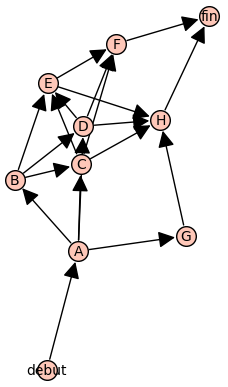

Distances : [0, 0, 2, 5, 5, 6, 7, 2, 7, 10]
Prédécesseurs : ['debut', 'debut', 'A', 'B', 'B', 'D', 'E', 'A', 'E', 'H']
Durée du projet : 10 jours
Il faut commencer le projet : 10 jours en avance.


In [26]:
# Construisons le graphe du projet
projet = DiGraph(weighted=True)

projet.add_edges([
    ("debut", "A", 0),
    ("A", "B", 2),
    ("A", "C", 2),
    ("A", "D", 2),
    ("A", "G", 2),
    ("B", "C", 3),
    ("B", "D", 3),
    ("B", "E", 3),
    ("C", "E", 1),
    ("C", "F", 1),
    ("C", "H", 1),
    ("D", "E", 1),
    ("D", "F", 1),
    ("D", "H", 1),
    ("E", "F", 1),
    ("E", "H", 1),
    ("G", "H", 3),
    ("F", "fin", 2),
    ("H", "fin", 3)
])

projet.show()

D, P = plus_long_chemin(projet)
print("Distances :", D)
print("Prédécesseurs :", P)

# Question 1 : combien de jours pour le projet ?
print("Durée du projet :", max(D), "jours")
print("Il faut commencer le projet :", max(D), "jours", "en avance.")


In [ ]:
# 2.Trouver le chemin critique
N = projet.topological_sort()
chemin = ["fin"]
sommet = "fin"
while sommet != "debut":
    i = trouver_position(N, sommet)
    sommet = P[i]
    chemin.append(sommet)

# retourner la liste à l'envers
chemin_final = []
i = len(chemin) - 1       
while i >= 0:              
    chemin_final.append(chemin[i])
    i = i - 1              

print("Chemin critique :", chemin_final)

Chemin critique : ['debut', 'A', 'B', 'D', 'E', 'H', 'fin']


In [ ]:
# 3. Les taches où on doit pas prendre de rétard c'est le chemin critique
#  parce qu'il est le plus long chemin du projet.

# EXERCICE 5:

In [27]:
# Le tri topologique (méthode vue en TD):

def tri_topologique(g):
    # copions la liste des arêtes
    aretes = []
    for arete in g.edges():
        aretes.append(arete)

    # trouvons tous les sommets
    sommets = []
    for arete in aretes:
        if arete[0] not in sommets:
            sommets.append(arete[0])
        if arete[1] not in sommets:
            sommets.append(arete[1])

    resultat = []

    while len(resultat) < len(sommets):
        for s in sommets:
            if s in resultat:
                continue

            a_un_pred = False
            for arete in aretes:
                if arete[1] == s:
                    a_un_pred = True

            if a_un_pred == False:
                resultat.append(s)

                nouvelles_aretes = []
                for arete in aretes:
                    if arete[0] != s:
                        nouvelles_aretes.append(arete)
                aretes = nouvelles_aretes

    return resultat

print("Tri topologique :", tri_topologique(g))


Tri topologique : [1, 3, 5, 2, 4]


In [ ]:
# conclusionn: la fonction que je viens d'écrire et celle nommée topological_sort() sont différentes dans l'ordre !